# 01_回归算法-弹性网络回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿想和大家来聊聊在回归算法中，重要的一个算法模型：弹性网络回归！

首先说，**回归算法**是一种用于预测连续值的机器学习方法。

例如，如果我们想预测一个人根据他的身高、年龄和饮食习惯可能有多重，这就是一个回归问题。

数学上，回归算法的核心是找到一个公式，将输入（特征）与输出（目标值）联系起来。常见的公式形式是：


$$
y = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b
$$


其中：

- $x_1, x_2, \ldots, x_n$：是输入特征
- $w_1, w_2, \ldots, w_n$：是权重（回归系数）
- $b$：是偏置
- $y$：是预测值

目标是通过训练数据找到最合适的权重和偏置，使得预测值 $y$ 和真实值尽可能接近。

那么弹性回归网络是什么？

## 弹性网络回归是什么？

**弹性网络回归（Elastic Net Regression）** 是一种回归算法，结合了两种正则化方法：

1. **L1 正则化（Lasso）**：让部分不重要的权重变为零，从而实现特征选择。
2. **L2 正则化（Ridge）**：让权重变得更平滑，避免过拟合。

弹性网络回归的损失函数是：


$$
L(w, b) = \frac{1}{2n} \sum_{i=1}^n (y_i - X_i w - b)^2 + \alpha \cdot \left( \rho \|w\|_1 + \frac{1 - \rho}{2} \|w\|_2^2 \right)
$$


$\alpha$：控制正则化强度。

$\rho$：在 L1（特征选择）和 L2（平滑权重）之间进行权衡。

### 案例：选择水果供应商

假设你经营水果店，需要根据以下几个因素选择供应商：

1. **价格（每斤）** ($x_1$)
2. **配送时间（小时）** ($x_2$)
3. **水果质量评分（1-10 分）** ($x_3$)

你的目标是预测每个供应商的**综合满意度评分**（连续值，1-10 分），你手上有一些历史数据可以用来训练模型。

| 供应商 | 价格 ($x_1$) | 配送时间 ($x_2$) | 质量评分 ($x_3$) | 满意度 ($y$) |
|-|-|-|-|-|
| A | 5 | 24 | 9 | 8.5 |
| B | 6 | 36 | 8 | 7.0 |
| C | 4 | 48 | 7 | 6.0 |
| D | 5.5 | 30 | 9 | 8.0 |

现在呢，希望模型能告诉你未来哪个供应商最可能满足你的需求。

### 手动计算一个简单例子

假设我们用一个简单的线性回归模型，不带正则化：


$$
y = w_1x_1 + w_2x_2 + w_3x_3 + b
$$


假设通过训练，我们得到了以下权重和偏置：

$w_1 = -0.5$（价格越高，满意度越低）

$w_2 = -0.02$（配送时间越长，满意度越低）

$w_3 = 1.0$（质量越高，满意度越高）

$b = 5.0$（基础满意度）

现在我们想预测一个新的供应商的数据：

- 价格 $x_1 = 5$
- 配送时间 $x_2 = 40$
- 质量评分 $x_3 = 8$

代入公式：  
$y = -0.5 \cdot 5 + (-0.02) \cdot 40 + 1.0 \cdot 8 + 5.0$

逐步计算：


$$
-0.5 \cdot 5 = -2.5
$$


$$
-0.02 \cdot 40 = -0.8
$$


$$
1.0 \cdot 8 = 8.0
$$


1. 合计 $-2.5 - 0.8 + 8.0 + 5.0 = 9.7$

预测的满意度为 **9.7**，说明这个供应商可能是个不错的选择。

### 为什么需要弹性网络回归？

如果数据中有很多特征（比如 1000 个特征），可能有以下问题：

1. **不相关特征**：有些特征可能对结果几乎没有影响，应该忽略。
2. **多重共线性**：多个特征之间可能高度相关（例如「价格」和「折扣」），这会让模型难以确定权重。

弹性网络回归通过：

- **L1 正则化**：自动将不重要的特征权重设置为 0（特征选择）。
- **L2 正则化**：让权重更平滑，避免过拟合。

### 总结4点

- 普通回归：根据历史数据找出一个公式，预测结果。
- Lasso：更倾向于忽略不重要的特征。
- Ridge：更倾向于平滑权重，防止过拟合。
- 弹性网络回归：结合了 Lasso 和 Ridge 的优点，既能选特征，又能让模型稳定。

## 公式解析

### 1. 回归算法的数学背景

#### 普通线性回归公式

普通线性回归的目标是找到一个线性模型，使得输入特征 $X$ 和目标变量 $y$ 之间的关系最佳拟合，公式如下：


$$
\hat{y} = Xw + b
$$


其中：

$X$：输入特征矩阵（形状为 $n \times p$，$n$ 是样本数量，$p$ 是特征数量）。

$w$：权重向量（形状为 $p \times 1$）。

$b$：偏置项（标量）。

$\hat{y}$：模型的预测值。

目标是最小化均方误差（MSE）：


$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2
$$


展开后，目标等价于最小化以下目标函数：


$$
\text{MSE}(w, b) = \frac{1}{n} \| y - (Xw + b) \|_2^2
$$


#### 引入正则化的需求

普通线性回归可能会出现以下问题：

1. **过拟合**：模型对训练数据过于敏感，导致泛化能力差。
2. **多重共线性**：特征之间高度相关，导致权重不稳定。

为解决上述问题，**正则化方法**被引入，常见的有 L1 正则化（Lasso）和 L2 正则化（Ridge）。

### 2. 弹性网络回归的数学推导

#### 损失函数

弹性网络回归结合了 L1 正则化和 L2 正则化，其损失函数为：


$$
L(w, b) = \frac{1}{n} \| y - (Xw + b) \|_2^2 + \alpha \left( \frac{1-\rho}{2} \| w \|_2^2 + \rho \| w \|_1 \right)
$$


其中：

$\| y - (Xw + b) \|_2^2$：数据误差（最小化预测值与真实值之间的误差）。

$\| w \|_1 = \sum_{j=1}^p |w_j|$：L1 正则化，倾向于让某些 $w_j$ 为 0（特征选择）。

$\| w \|_2^2 = \sum_{j=1}^p w_j^2$：L2 正则化，倾向于让权重分布平滑。

$\alpha > 0$：正则化强度，控制正则化项与误差项的权衡。

$\rho \in [0, 1]$：平衡 L1 和 L2 的比例。

#### 优化问题

弹性网络回归的问题可以写为：


$$
\min_{w, b} \; \frac{1}{n} \| y - (Xw + b) \|_2^2 + \alpha \left( \frac{1-\rho}{2} \| w \|_2^2 + \rho \| w \|_1 \right)
$$


#### 转化为矩阵形式

假设没有偏置项 $b$（可以通过扩展特征向量加入 $1$ 来处理），简化后的目标函数为：


$$
L(w) = \frac{1}{n} \| y - Xw \|_2^2 + \alpha \left( \frac{1-\rho}{2} \| w \|_2^2 + \rho \| w \|_1 \right)
$$


将误差项展开：


$$
\| y - Xw \|_2^2 = (y - Xw)^T(y - Xw) = y^Ty - 2y^TXw + w^TX^TXw
$$


因此，目标函数可以写为：


$$
L(w) = \frac{1}{n} \left( y^Ty - 2y^TXw + w^TX^TXw \right) + \alpha \left( \frac{1-\rho}{2} \| w \|_2^2 + \rho \| w \|_1 \right)
$$


### 3. 弹性网络回归的求解

#### 梯度计算

目标函数的梯度分两部分：

1. **误差项的梯度**：


$$
\nabla_w \frac{1}{n} \| y - Xw \|_2^2 = -\frac{2}{n} X^T(y - Xw)
$$


1. **正则化项的梯度**：

   - L2 正则化（$\| w \|_2^2$ 的梯度）为 $\frac{\partial}{\partial w} \frac{1}{2} \| w \|_2^2 = w$。
   - L1 正则化（$\| w \|_1$ 的梯度）为非光滑问题，使用次梯度求解，次梯度为：


$$
\frac{\partial |w_j|}{\partial w_j} =\begin{cases}1 & w_j > 0 \\-1 & w_j < 0 \\\text{任意值} \in [-1, 1] & w_j = 0\end{cases}
$$


#### 梯度下降法

将梯度合并，更新规则为：


$$
w^{(k+1)} = w^{(k)} - \eta \nabla_w L(w^{(k)})
$$


其中：

$\eta$：学习率。

$\nabla_w L(w^{(k)})$：目标函数的梯度。

#### 坐标下降法（Coordinate Descent）

由于 L1 正则化项导致目标函数不可导，弹性网络回归通常使用**坐标下降法**进行优化。方法如下：

1. 对每个权重 $w_j$ 逐一优化，固定其他权重不变。
2. 更新公式为（推导略）：


$$
w_j = S\left( \frac{1}{n} \sum_{i=1}^n x_{ij}(y_i - \hat{y}_i + w_jx_{ij}), \; \alpha \rho \right)
$$


其中 $S(z, \lambda)$ 是软阈值函数（Soft Thresholding）：


$$
S(z, \lambda) =\begin{cases}z - \lambda & z > \lambda \\0 & |z| \leq \lambda \\z + \lambda & z < -\lambda\end{cases}
$$


### 4. 弹性网络的直观理解

- 当 $\rho = 0$，弹性网络退化为 Ridge 回归（L2 正则化）。
- 当 $\rho = 1$，弹性网络退化为 Lasso 回归（L1 正则化）。
- 在 $\rho \in (0, 1)$ 时，弹性网络既能处理稀疏性（特征选择），又能避免多重共线性。

### 总结弹性网络回归

弹性网络回归的损失函数结合了数据误差和两种正则化：  
$L(w, b) = \frac{1}{n} \| y - (Xw + b) \|_2^2 + \alpha \left( \frac{1-\rho}{2} \| w \|_2^2 + \rho \| w \|_1 \right)$

通过梯度下降或坐标下降进行优化，最终得到一个权衡稀疏性和稳定性的模型。

## 完整案例

我们可以用一个包含多个特征的数据集来展示回归算法中的「弹性网络回归」的应用。

我们使用一个模拟的数据集，并依次进行以下步骤：

1. 生成数据集，使用多个特征进行建模。
2. 对数据进行弹性网络回归。
3. 可视化回归结果以及数据特征之间的关系。

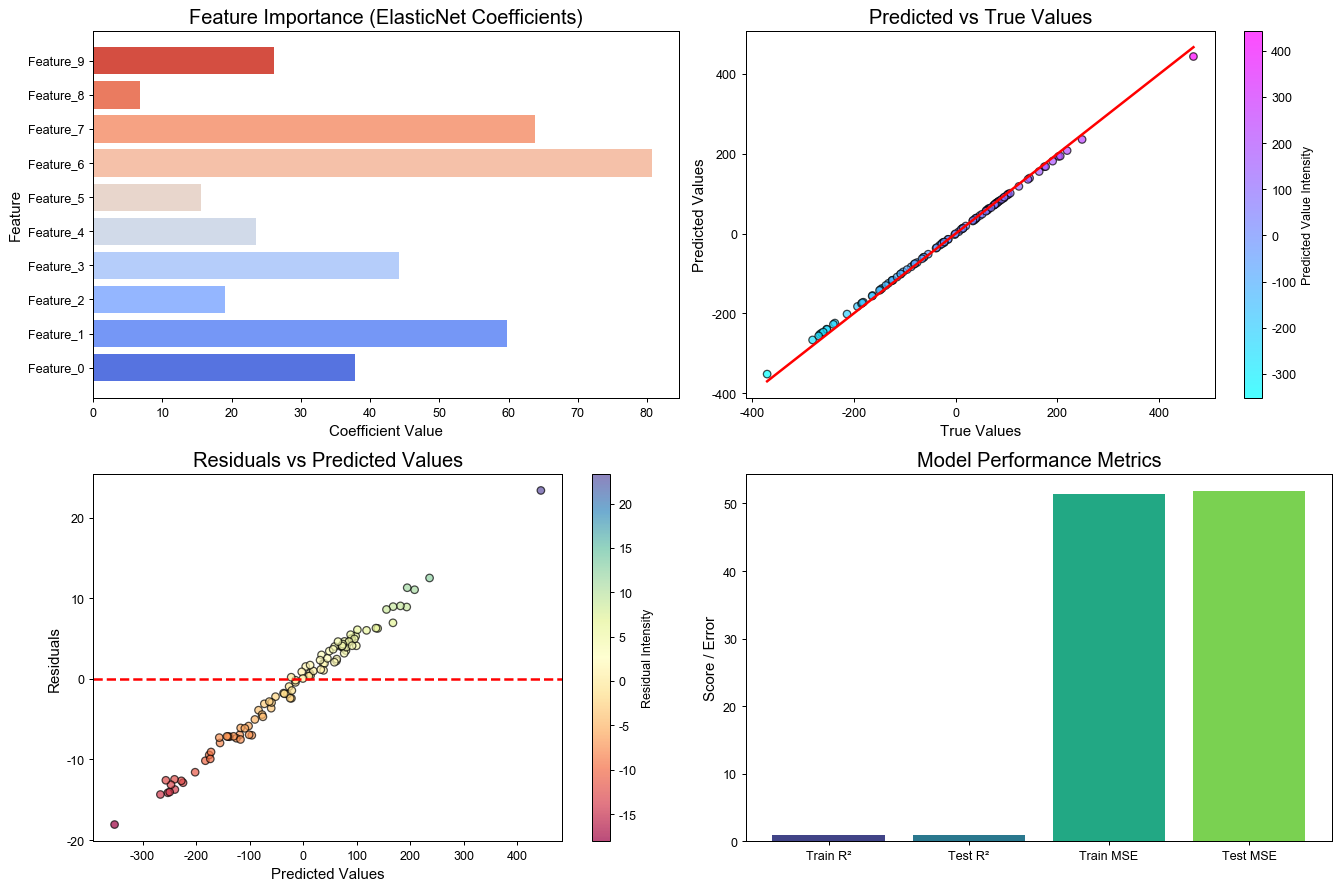

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error

# 1. 生成模拟数据集
X, y = make_regression(n_samples=500, n_features=10, noise=0.1, random_state=42)
X = pd.DataFrame(X, columns=[f"Feature_{i}" for i in range(10)])
y = pd.Series(y, name="Target")

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 弹性网络回归模型
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_net.fit(X_train_scaled, y_train)

# 5. 模型预测
y_pred_train = elastic_net.predict(X_train_scaled)
y_pred_test = elastic_net.predict(X_test_scaled)

# 6. 计算评价指标
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

# 7. 可视化分析
plt.figure(figsize=(15, 10))

# 图 1: 特征重要性（回归系数）
plt.subplot(2, 2, 1)
coef = elastic_net.coef_
colors = sns.color_palette("coolwarm", len(coef))
plt.barh(X.columns, coef, color=colors)
plt.title('Feature Importance (ElasticNet Coefficients)', fontsize=16)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)

# 图 2: 预测值与真实值的关系
plt.subplot(2, 2, 2)
plt.scatter(y_test, y_pred_test, c=y_pred_test, cmap='cool', alpha=0.7, edgecolor='k')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.title('Predicted vs True Values', fontsize=16)
plt.xlabel('True Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.colorbar(label="Predicted Value Intensity")

# 图 3: 预测残差图
plt.subplot(2, 2, 3)
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, c=residuals, cmap='Spectral', alpha=0.7, edgecolor='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs Predicted Values', fontsize=16)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.colorbar(label="Residual Intensity")

# 图 4: R^2 与 MSE 比较
plt.subplot(2, 2, 4)
metrics = ['Train R²', 'Test R²', 'Train MSE', 'Test MSE']
values = [r2_train, r2_test, mse_train, mse_test]
colors = sns.color_palette("viridis", len(metrics))
plt.bar(metrics, values, color=colors)
plt.title('Model Performance Metrics', fontsize=16)
plt.ylabel('Score / Error', fontsize=12)

plt.tight_layout()
plt.show()

1. **生成数据集**：我们使用 `make_regression` 生成一个包含500个样本和10个特征的模拟数据集。特征名称设置为 `Feature_0` 到 `Feature_9`，目标变量为 `y`。
2. **模型构建**：将数据分为训练集和测试集后，使用 `ElasticNet` 进行回归建模。模型中的 `alpha` 和 `l1_ratio` 分别控制正则化强度和Lasso与Ridge的权重比。
3. **模型评估**：通过 `R²` 和均方误差（MSE）评价模型的性能，并将结果可视化。

![原文参考图，当前结果见代码输出](attachments/img_004.png)

- **图1** 展示弹性网络回归中各个特征的重要性（即系数值）。
- **图2** 直观对比测试集中模型的预测值与真实值之间的关系。
- **图3** 展示预测值与残差之间的关系。
- **图4** 将训练集和测试集上的 `R²` 和 `MSE` 进行对比分析。

## 优缺点和适用场景

**优点**：

1. **特征选择能力：** 弹性网络包含 L1 正则化（Lasso），可以将不重要的特征权重收缩到 0，从而实现特征选择。特别适用于数据集中存在许多无关或冗余特征的情况。
2. **抗多重共线性：** 弹性网络包含 L2 正则化（Ridge），能有效处理多重共线性问题（即特征之间高度相关），通过平滑权重，避免不稳定的权重估计。
3. **平衡稀疏性和稳定性：** 通过调节参数 $\rho$，弹性网络在完全稀疏（L1）和完全平滑（L2）之间找到平衡，既适合特征稀疏的情况，也能处理非稀疏特征集。
4. **对高维数据的鲁棒性：** 当特征数量 $p$ 远大于样本数量 $n$ 时，弹性网络依然可以进行有效的回归分析。
5. **灵活性：** 参数 $\alpha$ 和 $\rho$ 提供了对正则化强度和正则化类型的灵活控制。

**缺点**：

1. **模型解释性较弱：** 虽然可以进行特征选择，但引入了 L2 正则化后，部分特征的权重可能不会完全归零，导致解释性不如纯 Lasso 回归直观。
2. **对参数敏感：** 弹性网络的表现依赖于 $\alpha$（正则化强度）和 $\rho$（L1/L2 平衡参数）的选择，需要借助交叉验证来调优，增加了计算成本。
3. **非稀疏特征时性能可能不如 Ridge：** 在特征稀疏性较低时，L2 正则化（Ridge）可能是更简单且更高效的选择。
4. **复杂度较高：** 由于结合了 L1 和 L2 正则化，优化问题的计算复杂度比单独的 Lasso 或 Ridge 要高。

### 适用场景

1. **高维数据场景（**$p > n$**）：** 当特征数量多于样本数量时（例如基因组数据分析），普通回归可能产生过拟合，而弹性网络通过正则化能有效缓解问题。
2. **特征多且存在冗余：** 数据集中存在许多特征，其中部分特征可能不相关或高度相关，弹性网络可以筛选出重要特征，并通过 L2 正则化处理多重共线性。
3. **需要平衡稀疏性和稳定性：** 如果既希望模型稀疏，又希望模型对特征间的共线性具有鲁棒性，弹性网络是最佳选择。
4. **变量重要性分析：** 在机器学习中希望进行变量重要性评估，并希望选择出对预测影响最大的特征。
5. **稀疏数据：** 如文本数据（词袋模型）或图像数据，特征矩阵通常是稀疏的，弹性网络可以高效处理这类问题。

总的来说，弹性网络回归就是一种很好用的回归方法，能在挑出重要特征的同时保持模型的稳定性。它结合了 Lasso 和 Ridge 的优点，既能去掉没用的特征，又能防止模型过拟合。特别适合那种特征很多、还有些特征相互关联的数据场景。\*